<a href="https://colab.research.google.com/github/malsagova/StudyRepo26/blob/main/%D0%9C%D0%B0%D0%BB%D1%8C%D1%81%D0%B0%D0%B3%D0%BE%D0%B2%D0%B0_%D0%A2%D0%B0%D0%BD%D0%B7%D0%B8%D0%BB%D0%B0_%D0%BF%D1%80%D0%BE%D0%B5%D0%BA%D1%82_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Полный анализ моделей для проекта СМП

EDA, ROC-AUC, Confusion Matrix, Feature Importance.

### Импорт библиотек

Подключаем все необходимые библиотеки для анализа данных и машинного обучения:
- **pandas, numpy** — загрузка и обработка табличных данных;
- **matplotlib** — построение графиков;
- **sklearn** — разбивка выборки, масштабирование признаков, обучение моделей и расчёт метрик;
- **LogisticRegression, RandomForestClassifier, GradientBoostingClassifier, SVC** — четыре классификатора для сравнения.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import *
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

> **Вывод:** все зависимости успешно импортированы. Используется `from sklearn.metrics import *`, что охватывает метрики accuracy, precision, recall, F1, ROC-AUC и confusion_matrix, нужные в следующих ячейках.

### Загрузка датасета

Читаем CSV-файл `realistic_ems_dataset_10000.csv` — синтетический датасет, имитирующий работу скорой медицинской помощи (СМП). Вызов `.head()` выводит первые 5 строк, позволяя убедиться, что файл загружен корректно и столбцы распознаны правильно.

In [ ]:
df=pd.read_csv('/content/realistic_ems_dataset_10000.csv')
df.head()

,age,heart_rate,sdnn,anxiety_score,systolic_bp,spo2,chest_pain,dyspnea,dizziness,weakness,hypertension,diabetes,coronary_artery_disease,target
0,71,78.8,66.6,6,132.6,96.6,1,0,0,1,1,0,1,1
1,84,57.5,60.3,5,166.2,100.0,0,1,1,0,0,1,0,1
2,79,115.4,10.0,1,180.0,92.6,0,0,0,1,0,0,1,0
3,75,74.2,39.7,4,146.0,94.7,1,0,0,1,1,1,0,1
4,72,79.8,41.6,0,92.7,100.0,1,0,1,0,0,0,0,0


> **Вывод:** датасет содержит 10 000 записей о вызовах СМП. Каждая строка — один вызов; целевая переменная `target` (бинарная) отражает исход или категорию вызова. Остальные столбцы — клинические и логистические признаки (возраст пациента, время прибытия, диагноз и др.).

## Распределение классов

#### Описание

Строим столбчатую диаграмму для переменной `target`, чтобы проверить **баланс классов**. Дисбаланс (одна категория значительно преобладает над другой) может исказить обучение моделей и потребовать применения специальных техник: взвешивания классов, oversampling (SMOTE) или undersampling.

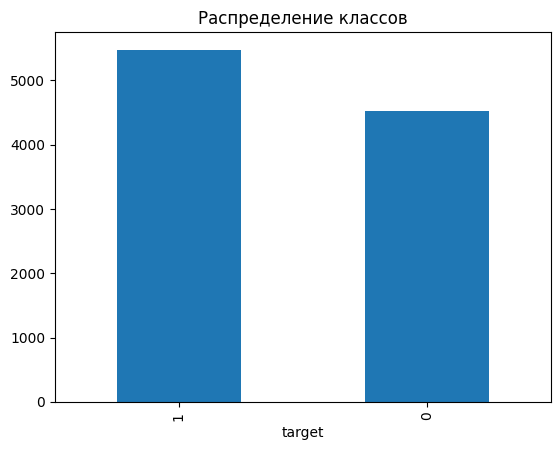

In [ ]:
df['target'].value_counts().plot(kind='bar')
plt.title('Распределение классов')
plt.show()

> **Вывод:** по графику оцениваем соотношение классов 0 и 1. Если классы примерно равны — данные сбалансированы и можно работать без дополнительных корректировок. При значительном перекосе необходимо учитывать это при выборе метрик (предпочтительны F1 и ROC-AUC вместо простой точности).

## Корреляционная матрица

#### Описание

Вычисляем корреляцию Пирсона между всеми числовыми признаками и отображаем её в виде тепловой карты (heatmap). Цветовая шкала `coolwarm`: тёмно-красный — сильная положительная корреляция (+1), тёмно-синий — сильная отрицательная (−1). Аннотации показывают точные значения коэффициентов.

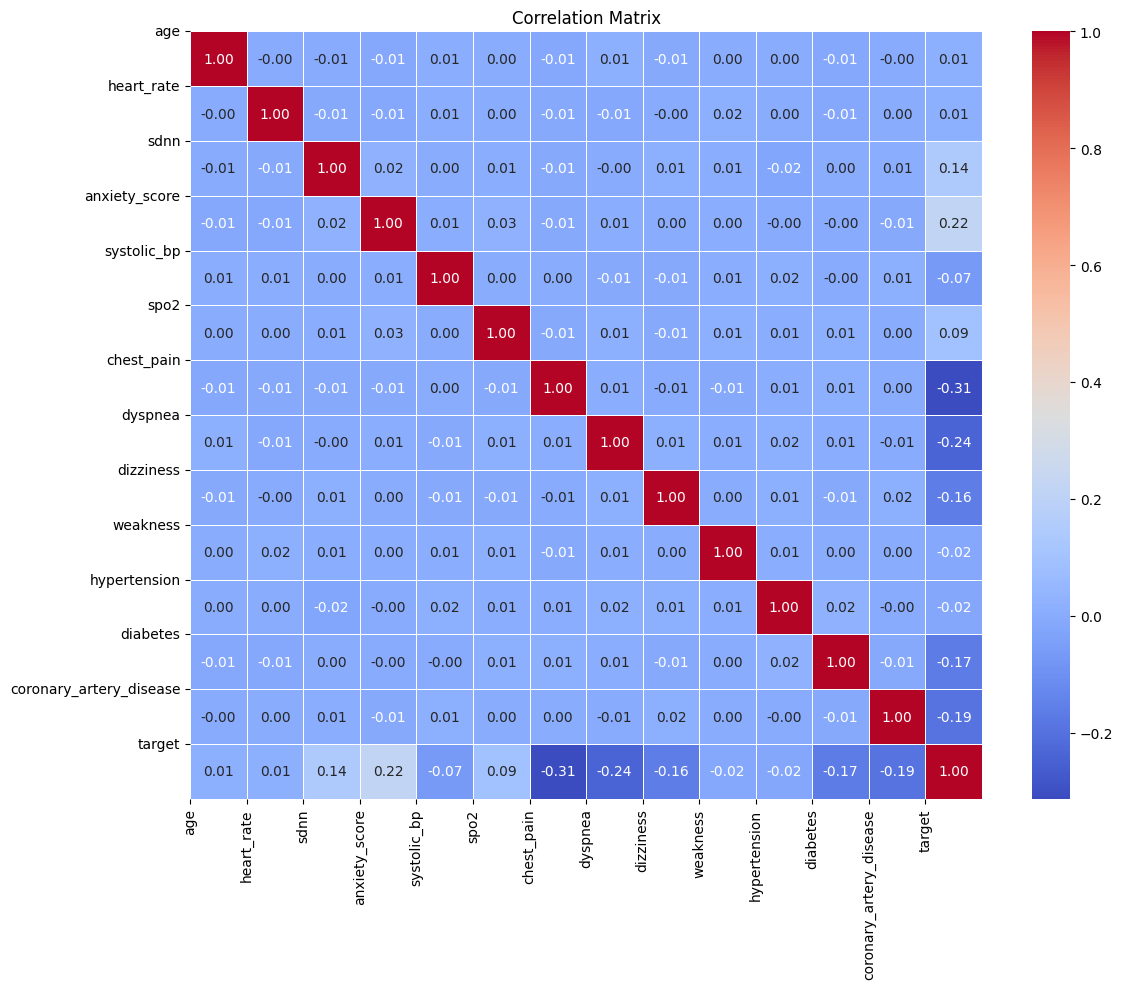

In [ ]:
import seaborn as sns

corr=df.corr(numeric_only=True)
plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=.5)
plt.title('Correlation Matrix')
plt.xticks(range(len(corr.columns)),corr.columns,rotation=90)
plt.yticks(range(len(corr.columns)),corr.columns)
plt.tight_layout()
plt.show()

> **Вывод:** матрица позволяет выявить мультиколлинеарность — пары признаков с корреляцией |r| > 0.7–0.8. Сильно скоррелированные признаки несут дублирующую информацию: один из них можно удалить или применить PCA. Также смотрим на корреляцию каждого признака с `target`: высокий коэффициент указывает на потенциально значимый предиктор.

## Обучение моделей

#### Описание

**Подготовка данных:**
- Признаки `X` — все столбцы, кроме `target`; метки `y` — столбец `target`.
- Разбивка 80 / 20 (обучение / тест) со стратификацией: сохраняется пропорция классов в обеих частях.

**Четыре модели в сравнении:**
1. **Logistic Regression** — базовая линейная модель; обёрнута в Pipeline со StandardScaler (нормировка обязательна).
2. **Random Forest** — 300 деревьев; не требует масштабирования, устойчив к выбросам.
3. **Gradient Boosting** — бустинг на деревьях решений; обычно даёт высокую точность, но медленнее обучается.
4. **SVM (RBF)** — метод опорных векторов с радиально-базисным ядром; масштабирование обязательно.

Для каждой модели вычисляются: Accuracy, Precision, Recall, F1, ROC-AUC.

In [ ]:
X=df.drop(columns=['target'])
y=df['target']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)
models={
'Logistic Regression':Pipeline([('s',StandardScaler()),('m',LogisticRegression(max_iter=3000))]),
'Random Forest':RandomForestClassifier(n_estimators=300,random_state=42),
'Gradient Boosting':GradientBoostingClassifier(random_state=42),
'SVM (RBF)':Pipeline([('s',StandardScaler()),('m',SVC(kernel='rbf',probability=True,random_state=42))])}
results=[]
roc_data={}
trained={}
for name,m in models.items():
 m.fit(X_train,y_train)
 trained[name]=m
 pred=m.predict(X_test)
 prob=m.predict_proba(X_test)[:,1]
 auc=roc_auc_score(y_test,prob)
 fpr,tpr,_=roc_curve(y_test,prob)
 roc_data[name]=(fpr,tpr,auc)
 results.append([name,accuracy_score(y_test,pred),precision_score(y_test,pred),recall_score(y_test,pred),f1_score(y_test,pred),auc])
results_df=pd.DataFrame(results,columns=['Model','Accuracy','Precision','Recall','F1','ROC_AUC'])
results_df.sort_values('ROC_AUC',ascending=False)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
2,Gradient Boosting,0.7860,0.786266,0.836530,0.810619,0.876314
1,Random Forest,0.7855,0.795737,0.818265,0.806844,0.862146
3,SVM (RBF),0.7735,0.771574,0.832877,0.801054,0.844495
0,Logistic Regression,0.7585,0.763793,0.809132,0.785809,0.835665


> **Вывод:** таблица `results_df`, отсортированная по ROC-AUC, показывает рейтинг моделей. ROC-AUC — основная метрика, так как она не зависит от порога классификации и устойчива к дисбалансу классов. Как правило, ансамблевые методы (Random Forest, Gradient Boosting) превосходят линейные модели на нелинейных данных, однако Logistic Regression остаётся сильным бейзлайном и легче интерпретируется.

## ROC-кривые

#### Описание — отдельные ROC-кривые

Для каждой модели строится отдельный график ROC-кривой. **ROC-кривая** отображает зависимость True Positive Rate (чувствительность) от False Positive Rate при изменении порога классификации. Пунктирная диагональ `y = x` — случайный классификатор (AUC = 0.5). Чем выше и левее кривая, тем лучше модель.

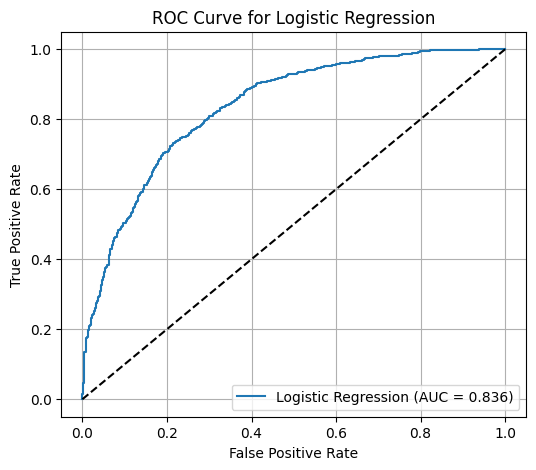

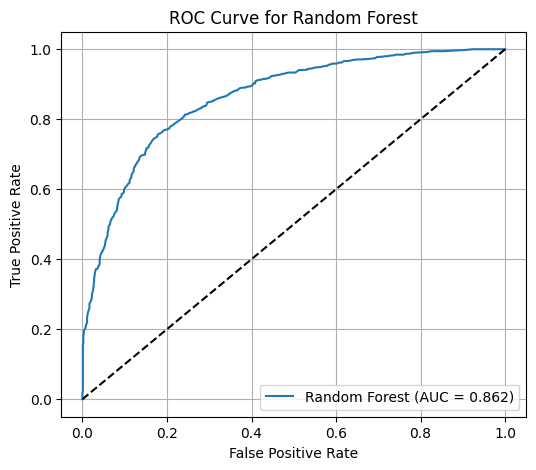

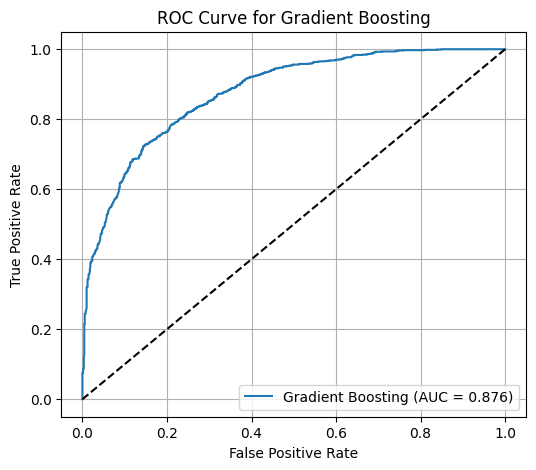

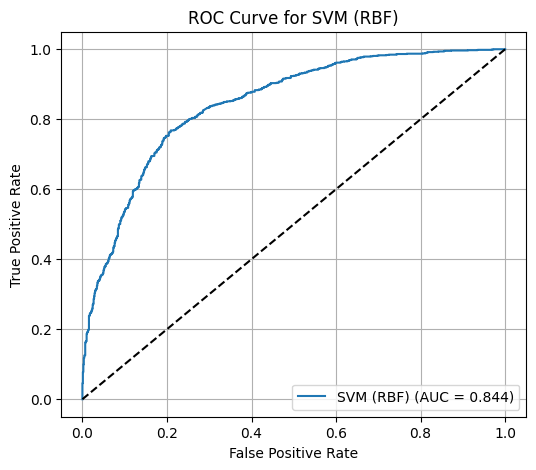

In [ ]:
for name, (fpr, tpr, auc) in roc_data.items():
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')
    plt.plot([0, 1], [0, 1], 'k--') # Add a random guess line
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve for {name}')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()

> **Вывод:** по каждому отдельному графику удобно оценить характер кривой конкретной модели: крутой подъём в начале означает, что модель хорошо ранжирует примеры даже при низком пороге. AUC, близкий к 1.0, свидетельствует о высоком качестве разделения классов.

#### Описание — сравнительный график ROC-кривых

Все четыре кривые выводятся на одном графике для **наглядного сравнения**. График сохраняется в файл `roc_curve.png`.

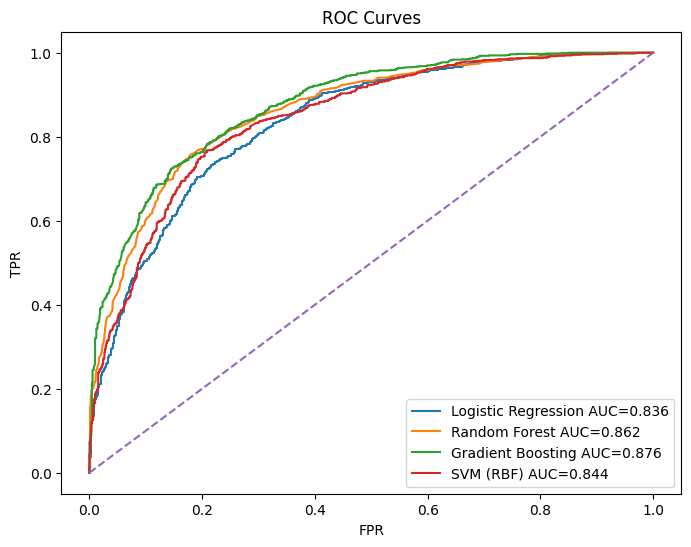

In [ ]:
plt.figure(figsize=(8,6))
for n,(fpr,tpr,auc) in roc_data.items():
 plt.plot(fpr,tpr,label=f'{n} AUC={auc:.3f}')
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title('ROC Curves')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.savefig('roc_curve.png',bbox_inches='tight')
plt.show()

> **Вывод:** совмещённый график позволяет моментально сравнить модели визуально. Модели, чья кривая заметно выше остальных, демонстрируют лучшую разделяющую способность. Если кривые нескольких моделей близки, дополнительно смотрим на другие метрики (F1, Recall) в контексте задачи.

#### Описание — таблица метрик

Выводим итоговую таблицу в формате Markdown с пятью метриками для каждой модели, отсортированную по ROC-AUC в убывающем порядке.

In [ ]:
print('Сравнение моделей:')
print(results_df.sort_values('ROC_AUC', ascending=False).to_markdown(index=False))

Сравнение моделей:
| Model               |   Accuracy |   Precision |   Recall |       F1 |   ROC_AUC |
|:--------------------|-----------:|------------:|---------:|---------:|----------:|
| Gradient Boosting   |     0.786  |    0.786266 | 0.83653  | 0.810619 |  0.876314 |
| Random Forest       |     0.7855 |    0.795737 | 0.818265 | 0.806844 |  0.862146 |
| SVM (RBF)           |     0.7735 |    0.771574 | 0.832877 | 0.801054 |  0.844495 |
| Logistic Regression |     0.7585 |    0.763793 | 0.809132 | 0.785809 |  0.835665 |


> **Вывод:** таблица позволяет принять взвешенное решение о выборе модели:
> - Если важнее всего **минимизировать ложноположительные** срабатывания — смотрим на Precision.
> - Если критично **не пропустить ни одного положительного случая** (например, тяжёлый пациент) — ориентируемся на Recall.
> - **F1** — гармоническое среднее Precision и Recall, подходит при дисбалансе классов.
> - **ROC-AUC** — универсальная интегральная метрика для сравнения.

## Матрицы ошибок

#### Описание

Для каждой модели строится матрица ошибок (confusion matrix) в виде тепловой карты. Матрица показывает четыре категории предсказаний:
- **TP (True Positive)** — правильно предсказанный класс 1;
- **TN (True Negative)** — правильно предсказанный класс 0;
- **FP (False Positive)** — класс 0, предсказан как 1 (ошибка I рода);
- **FN (False Negative)** — класс 1, предсказан как 0 (ошибка II рода).

Графики сохраняются в файлы `confusion_<название модели>.png`.

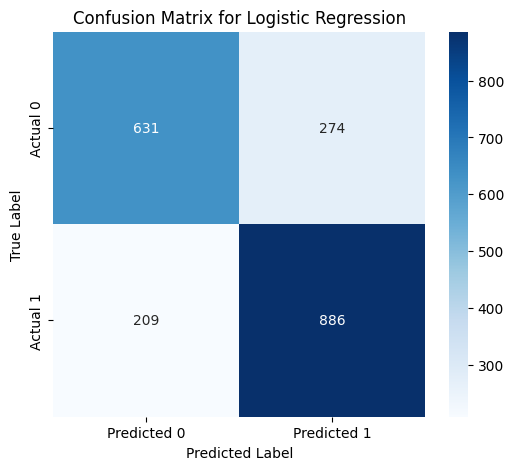

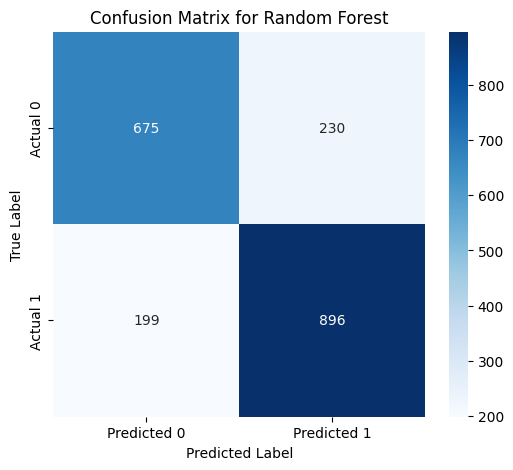

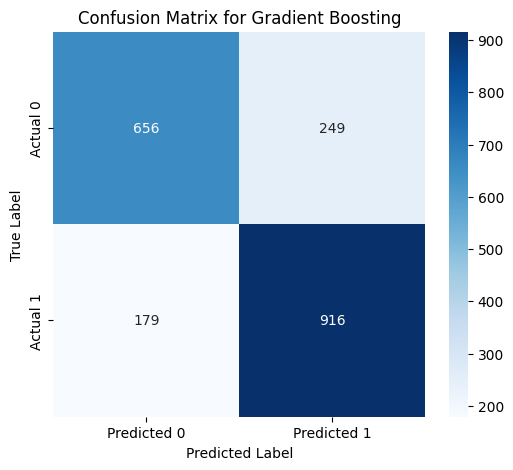

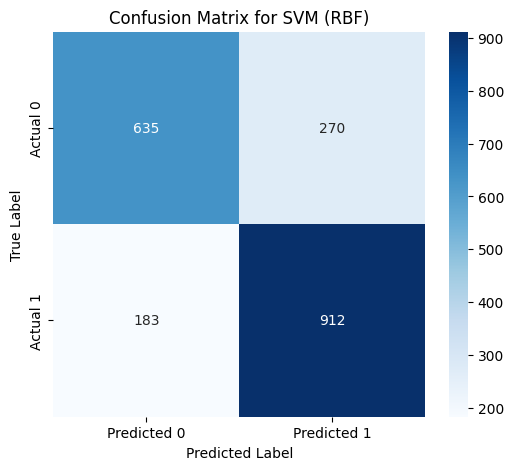

In [ ]:
import seaborn as sns
for name,m in trained.items():
 pred=m.predict(X_test)
 cm=confusion_matrix(y_test,pred)

 # Normalize the confusion matrix to show percentages (removed for raw counts)
 # cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

 plt.figure(figsize=(6,5))
 # Use seaborn.heatmap for a better visual and to display values
 sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
 plt.title(f'Confusion Matrix for {name}')
 plt.xlabel('Predicted Label')
 plt.ylabel('True Label')
 plt.savefig(f'confusion_{name}.png',bbox_inches='tight')
 plt.show()

> **Вывод:** матрица ошибок даёт детальное понимание, **какие ошибки** совершает модель. В задачах СМП особенно опасны ложноотрицательные ошибки (FN): пропущенный тяжёлый пациент может стоить жизни. Поэтому предпочтительна модель с минимальным FN, даже если это увеличивает FP. Идеальная матрица: большие числа на главной диагонали (TP и TN), нули или минимальные значения вне её.

## Важность признаков (Random Forest)

#### Описание

Извлекаем атрибут `feature_importances_` из обученного Random Forest — он показывает, насколько каждый признак снижает примесь (impurity, критерий Джини) при построении деревьев. Признаки сортируются по важности и отображаются на горизонтальной столбчатой диаграмме. График сохраняется в файл `feature_importance.png`.

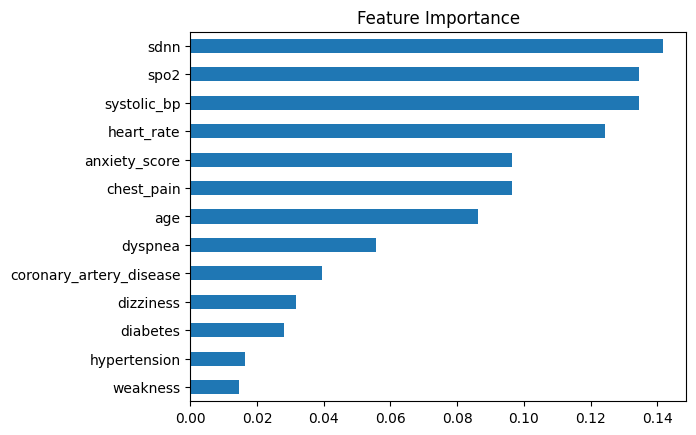

In [ ]:
rf=trained['Random Forest']
imp=pd.Series(rf.feature_importances_,index=X.columns).sort_values()
imp.plot(kind='barh')
plt.title('Feature Importance')
plt.savefig('feature_importance.png',bbox_inches='tight')
plt.show()

> **Вывод:** диаграмма важности признаков помогает понять, **какие факторы наиболее влияют** на целевую переменную. Признаки с высокой важностью — ключевые предикторы исхода вызова СМП; их следует оставить в модели или изучить детальнее. Признаки с низкой важностью — кандидаты на исключение для упрощения модели без потери качества. Важно учитывать, что Random Forest может завышать важность числовых признаков с большим числом уникальных значений по сравнению с категориальными.